In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict

In [17]:
df_pristine = pd.read_csv('results/clean_data/df_all_columns.csv')
df_clean = pd.read_csv('results/clean_data/df_clean.csv')

print(f'Размерность df_pristine: {df_pristine.shape}')
print(f'Размерность df_clean: {df_clean.shape}')

Размерность df_pristine: (11430, 89)
Размерность df_clean: (11430, 82)


In [18]:
Xp = df_pristine.drop(columns=['status', 'class_status'])
yp = df_pristine['class_status']

Xc = df_clean.drop('class_status', axis=1)
yc = df_clean['class_status']

models = {
    'DT': DecisionTreeClassifier(max_depth=6, random_state=42),
    'RF': RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42),
    'GB': GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.06, random_state=42)
}

In [19]:
results = []

def scoring_models(*args, obj_models, save, part):
    X, y = args
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for model_name, model in obj_models.items():
        scores_accuracy = cross_val_score(model, X, y, cv=stratified_kfold, n_jobs=-1, scoring='accuracy')
        scores_auc = cross_val_score(model, X, y, cv=stratified_kfold, n_jobs=-1, scoring='roc_auc')
        
        save.append({
            'model': model_name + part,
            'accuracy': round(scores_accuracy.mean(), 2) * 100,
            'roc_auc': round(scores_auc.mean(), 2) * 100
        })
        
def roc_curve_plots(*args, obj_models, part):
    X, y = args
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for model_name, model in obj_models.items():
        y_proba = cross_val_predict(model, X, y, cv=stratified_kfold, n_jobs=-1, method='predict_proba')[:, 1]
        fpr, tpr, _ = roc_curve(y, y_proba)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f'{model_name + part} (AUC: {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'results/ml/graphic/roc_curve_{part}.png')
    plt.show()

In [20]:
scoring_models(Xp, yp, obj_models=models, save=results, part='Pristine')
scoring_models(Xc, yc, obj_models=models, save=results, part='Clean')

df_metrics = pd.DataFrame(results)
df_metrics.to_excel('results/ml/result/metrics.xlsx')
df_metrics.head(6)

,model,accuracy,roc_auc
0,DTPristine,93.0,97.0
1,RFPristine,94.0,98.0
2,GBPristine,96.0,99.0
3,DTClean,93.0,97.0
4,RFClean,94.0,98.0
5,GBClean,96.0,99.0


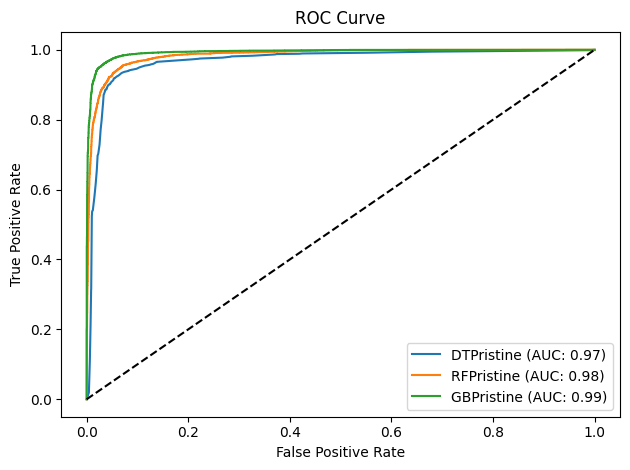

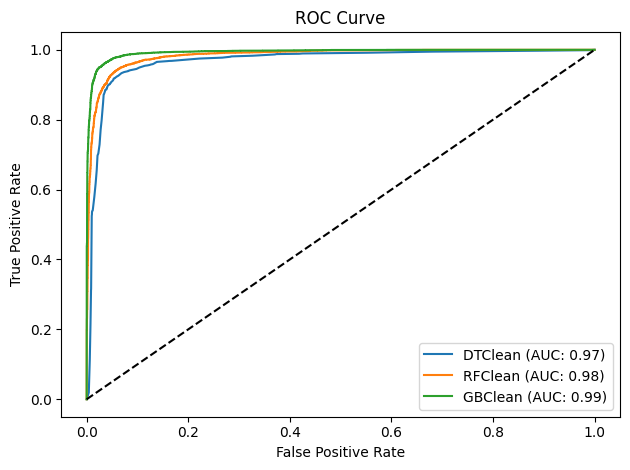

In [21]:
roc_curve_plots(Xp, yp, obj_models=models, part='Pristine')
roc_curve_plots(Xc, yc, obj_models=models, part='Clean')